# Chapter 19. 토크나이저 직접 학습 — WordPiece vs WordLevel (영어 + 한국어)

**목표**: Phase 3 의 첫 챕터. 지금까지 (Ch 7-18) 우리는 *사전학습된* 토크나이저 (`distilbert-base-uncased`, `klue/bert-base`) 를 그저 *불러* 썼습니다. 이번 챕터에서 **토크나이저 자체를 직접 학습** 해 봅니다 — *어떻게* 만들어지는지, 알고리즘이 다르면 *어떻게 다른 결과* 가 나오는지를 두 언어 × 두 알고리즘 = 네 가지 조합으로 비교.

**환경**: Google Colab T4 (모델 학습이 없어 GPU 거의 안 씀, 일관성 위해 T4 metadata 유지).

**예상 소요 시간**: 약 5-7분 (데이터 다운로드 -2분 + 토크나이저 4종 학습 -2분 + 시각화·비교)

---

## 학습 흐름

1. 🔤 **이론**: WordPiece (subword) vs WordLevel (어절 단위). BERT 가 WordPiece 를 쓰는 이유.
2. 📥 **코퍼스 준비**: 영어 Yelp text 5,000건 + 한국어 NSMC text 5,000건.
3. 🚀 **실습** — 4개 토크나이저 학습:
   - 영어 Yelp + WordPiece (vocab 8000)
   - 한국어 NSMC + WordPiece (vocab 8000)
   - 영어 Yelp + WordLevel (vocab 8000)
   - 한국어 NSMC + WordLevel (vocab 8000)
4. 🔬 **해부**: 같은 문장을 4 토크나이저에 통과 → 토큰 시퀀스 비교.
5. 📊 **비교 시각화**: 토큰 길이 분포 (4 토크나이저 × 같은 텍스트), unknown 비율, 2×2 요약 표.
6. 💾 **저장·로드**: `tokenizer.save()` / `Tokenizer.from_file()` + `PreTrainedTokenizerFast` 로 HF 인터페이스 변환.
7. 🛠️ **변형**: vocab 크기 sweep (1K / 4K / 8K / 16K).

---

> 📒 **사전 학습 자료**: Ch 7 (DistilBERT WordPiece 첫 사용), Ch 15 (한국어 WordPiece). 토크나이저는 이전 챕터들에서 *결과* 만 사용했고, 이번 챕터는 그 결과가 *어떻게 만들어지는지* 를 직접 봅니다.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output | Loss |
|---|---|---|---|---|---|
| 17 | klue/bert-base | WordPiece (한국어, 사전학습) | KLUE-YNAT 합성 multi-label | `Linear(H, 7)` | `BCEWithLogitsLoss` |
| 18 | klue/bert-base + 보조 | WordPiece (한국어, 사전학습) | KLUE-YNAT 합성 + 보조 라벨 | 메인(7) + 보조 | `BCEWithLogitsLoss + λ·L_aux` |
| **19 ← 여기 (Phase 3 시작)** | — (토크나이저 학습 전용) | **WordPiece + WordLevel** (둘 다 *직접 학습*) | **Yelp text + NSMC text** | — | — |
| 20 (다음) | 작은 BERT (직접, scratch) | `bert-base-uncased` 토크나이저 (가져옴) | Yelp text | MLM head | `CrossEntropyLoss` (masked) |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

**Phase 3 의 위치** — Ch 19 가 토크나이저 토대, Ch 20-23 은 그 위에 올린 작은 BERT 의 사전학습 + 분류. 단, Ch 20 부터는 *학습 안정성* 을 위해 표준 사전학습 토크나이저 (`bert-base-uncased`, `klue/bert-base`) 를 그대로 가져와 씁니다. Ch 19 는 "토크나이저가 어떻게 학습되나" 를 *경험* 하는 챕터.

## 🔄 변경점 (Diff from Ch 18)

| 축 | Ch 18 (한국어 auxiliary) | Ch 19 (토크나이저 학습 전용) |
|---|---|---|
| **이 챕터의 task** | 분류 (메인 multi-label + 보조) | **분류 아예 없음 — 토크나이저 학습 그 자체가 결과물** ← *유일한 변화* |
| 모델 | `klue/bert-base` 파인튜닝 | 없음 |
| 토크나이저 | 사전학습된 것 *로드만* | **WordPiece + WordLevel 둘 다 *직접 학습*** |
| 데이터 | KLUE-YNAT 합성 multi-label + 보조 라벨 | Yelp text + NSMC text (라벨 무시, *문장만* 사용) |
| Output / Loss | 메인 + 보조 + λ | 없음 (vocab + merge rules 가 산출물) |
| 평가 metric | F1 / AUC / MAE | 토큰 길이 분포 / UNK 비율 / vocab 커버리지 |

> **변경점 한 가지 원칙** — Phase 2 (분류 task) 의 종착인 Ch 18 에서 *task 자체* 가 토크나이저 학습으로 바뀝니다. 모델·loss·평가가 모두 사라지는 큰 전환이지만, 이건 *축 자체* 가 바뀌는 Phase 경계라 자연스러움. Phase 3 의 다음 챕터부터 다시 모델 학습으로 돌아갑니다.

### 왜 토크나이저를 *직접* 학습해야 하나

새 도메인 (의료·법률·코드 등) 이나 새 언어로 BERT 를 사전학습할 때, 기존 토크나이저는 *그 도메인의 어휘* 를 제대로 못 쪼갭니다. 예: 영어 토크나이저로 한국어를 처리하면 거의 모든 토큰이 `[UNK]` 가 됩니다. 도메인·언어에 맞춘 토크나이저를 직접 학습해야 모델이 *압축된* 정보를 받을 수 있어요.

## 📐 토크나이저 알고리즘 노트 — WordPiece vs WordLevel

이번 챕터의 핵심 비교는 *Loss 변화* 가 아니라 **토크나이저 알고리즘 변화** 입니다. 두 알고리즘은 분할 단위 자체가 다릅니다.

### WordLevel — 단순 어절 (whole-word)

공백 단위로 단어를 잘라 그대로 vocab 에 등록. *변형* 처리 없음.

- 학습: 코퍼스에서 *빈도 상위 N 단어* 를 골라 vocab 에 넣음. 나머지는 모두 `[UNK]`.
- 장점: 토큰화가 *즉시* 이해 가능 (한 단어 = 한 토큰).
- 단점: vocab 밖 단어 = 전부 `[UNK]`. 영어처럼 굴절·합성이 많은 언어에서 OOV 가 폭증.

### WordPiece — subword (BERT 표준)

자주 등장하는 *조각* 을 vocab 에 등록하고, 모르는 단어는 더 작은 조각으로 *재귀적으로 쪼갬*. BERT 시리즈 (BERT / DistilBERT / KLUE-BERT) 가 이 알고리즘을 씁니다.

- 학습: 처음에는 *문자 단위 vocab* 부터 시작 → likelihood 가 가장 많이 오르는 *문자 쌍* 을 vocab 에 병합 → vocab 목표 크기까지 반복.
- 처음 등장 토큰은 `playing`, 그 뒤를 잇는 조각은 `##ing` 처럼 `##` prefix.
- 장점: 모르는 단어도 *작은 조각* 으로 쪼개 표현 가능 → `[UNK]` 거의 안 남음.
- 단점: 짧은 단어 하나가 여러 조각으로 쪼개져 토큰 수가 늘어남.

### 수치 예시 (같은 문장이 두 알고리즘에서 몇 토큰?)

학습된 두 토크나이저가 *같은 문장* 을 어떻게 처리하나를 미리 감 잡기 — 실제 결과는 §4 에서 직접 확인합니다.

| 문장 | WordPiece (vocab 8K) | WordLevel (vocab 8K) |
|---|---|---|
| `"the food was great"` (4 단어, 흔한 어휘) | 4 토큰 (1 단어=1 piece) | 4 토큰 (모두 vocab) |
| `"unforgettable experience"` (드문 어휘) | 5 토큰 (`un`, `##forget`, `##table`, `experience`) | 2 토큰 — 단, `unforgettable` 이 vocab 밖이면 `[UNK]` |
| `"이 영화 정말 재미있어요"` (한국어) | 5-7 토큰 (조사·어미 분리) | 4 토큰 (어절 단위) — 단, `재미있어요` vocab 밖이면 `[UNK]` |

핵심 관찰: **WordLevel 은 "단어가 vocab 에 있느냐 없느냐" 의 binary** — 있으면 1 토큰, 없으면 `[UNK]`. **WordPiece 는 "얼마나 잘게 쪼갤지" 의 spectrum** — 흔한 단어는 1 토큰, 드문 단어는 여러 조각.

### BERT 가 WordPiece 를 쓰는 이유

(1) `[UNK]` 토큰이 거의 안 생겨 모든 단어가 *학습 가능* 한 표현으로 인코딩됨. (2) vocab 크기가 작아도 (BERT 30K, KLUE 32K) *어휘 커버리지* 가 좋음. (3) 미세한 형태 차이 (`run`/`running`/`runs`) 가 *공통 조각* 으로 묶여 표현 학습이 효율적.

## 🔤 토크나이저 노트 — 이 챕터의 *주제* 자체

지금까지의 모든 챕터에서 마지막 자리를 차지하던 이 섹션이, 이번엔 챕터의 *전체* 입니다.

- **Ch 7-14**: 영어 WordPiece (`distilbert-base-uncased`, vocab 30K, 사전학습) 받아 쓰기.
- **Ch 15-18**: 한국어 WordPiece (`klue/bert-base`, vocab 32K, 사전학습) 받아 쓰기.
- **Ch 19 (지금)**: *같은 WordPiece 알고리즘* + 단순 비교용 WordLevel 을 두 언어 코퍼스에서 *직접* 학습.
- **Ch 20+**: 다시 표준 사전학습 토크나이저로 — 단, *이제는 그 안에서 무엇이 벌어지는지 알고* 사용.

같은 알고리즘이 *언어가 바뀌면 어떻게 다른 결과* 를 내는지 (영어 vs 한국어), *알고리즘이 바뀌면 어떻게 다른 결과* 를 내는지 (WordPiece vs WordLevel) — 2×2 비교가 이 챕터의 핵심.

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U tokenizers transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 31.8/48.9 MB 222.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 191.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 191.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 191.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.1 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordPiece, WordLevel
from tokenizers.trainers import WordPieceTrainer, WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace, BertPreTokenizer
from tokenizers.normalizers import NFD, Lowercase, StripAccents, Sequence as NormSequence
from tokenizers.processors import TemplateProcessing
from tokenizers.decoders import WordPiece as WordPieceDecoder
from transformers import PreTrainedTokenizerFast

plt.rcParams["axes.unicode_minus"] = False

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
else:
    print("Note: this chapter does not train a model, so CPU is fine.")

PyTorch:        2.11.0+cu128
CUDA available: True
GPU:             Tesla T4


## 1. 📥 영어 코퍼스 — Yelp text 5,000건

`yelp_polarity` 의 train split 에서 5,000 문장만 sample. *라벨은 무시* — 이번 챕터는 *문장 자체* 만 필요.

In [3]:
SEED = 42
N_EN = 5000

ds_yelp = load_dataset("fancyzhx/yelp_polarity", split=f"train[:{N_EN}]")
texts_en = list(ds_yelp["text"])
print(f"english corpus: {len(texts_en):,} sentences")
print(f"first sample (truncated):\n  {texts_en[0][:200]}...")
print(f"\nchar length stats:")
char_lens_en = [len(t) for t in texts_en]
print(f"  mean: {np.mean(char_lens_en):.0f}, median: {np.median(char_lens_en):.0f}, max: {max(char_lens_en)}")

README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

english corpus: 5,000 sentences
first sample (truncated):
  Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply ...

char length stats:
  mean: 735, median: 548, max: 5038


## 2. 📥 한국어 코퍼스 — NSMC text 5,000건

Ch 15 와 같은 패턴으로 e9t/nsmc GitHub raw 에서 직접 다운로드. 라벨 무시, `document` 컬럼만 사용.

In [4]:
TRAIN_URL = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"

print("downloading NSMC train from GitHub...")
df_nsmc = pd.read_csv(TRAIN_URL, sep="\t").dropna(subset=["document"])
print(f"  total rows: {len(df_nsmc):,}")

N_KO = 5000
texts_ko = df_nsmc["document"].sample(n=N_KO, random_state=SEED).tolist()
print(f"\nkorean corpus: {len(texts_ko):,} sentences")
print(f"first sample:\n  {texts_ko[0]}")
print(f"\nchar length stats:")
char_lens_ko = [len(t) for t in texts_ko]
print(f"  mean: {np.mean(char_lens_ko):.0f}, median: {np.median(char_lens_ko):.0f}, max: {max(char_lens_ko)}")

downloading NSMC train from GitHub...


  total rows: 149,995

korean corpus: 5,000 sentences
first sample:
  원본이 최고

char length stats:
  mean: 34, median: 26, max: 143


## 3. 🚀 토크나이저 4종 학습

같은 두 코퍼스 (영어 / 한국어) × 두 알고리즘 (WordPiece / WordLevel) = 4 개.

**공통 hyperparams**:
- `vocab_size = 8000` — 입문 비교용 작은 크기 (BERT 표준은 30K 안팎)
- 특수 토큰: `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]`, `[MASK]` (BERT 컨벤션)
- pre-tokenizer: `Whitespace` (공백·구두점 단위로 1차 분할)
- WordPiece 만 normalizer 적용 (NFD + StripAccents + Lowercase)

In [5]:
SPECIAL_TOKENS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
VOCAB_SIZE = 8000


def build_wordpiece(corpus_iter, vocab_size=VOCAB_SIZE, lowercase=True):
    '''같은 corpus 에 대해 WordPiece 토크나이저를 학습해 반환.'''
    tok = Tokenizer(WordPiece(unk_token="[UNK]"))
    norms = [NFD(), StripAccents()]
    if lowercase:
        norms.append(Lowercase())
    tok.normalizer = NormSequence(norms)
    tok.pre_tokenizer = BertPreTokenizer()
    tok.decoder = WordPieceDecoder(prefix="##")

    trainer = WordPieceTrainer(
        vocab_size=vocab_size,
        special_tokens=SPECIAL_TOKENS,
        continuing_subword_prefix="##",
        show_progress=False,
    )
    tok.train_from_iterator(corpus_iter, trainer=trainer)

    cls_id = tok.token_to_id("[CLS]")
    sep_id = tok.token_to_id("[SEP]")
    tok.post_processor = TemplateProcessing(
        single="[CLS] $A [SEP]",
        pair="[CLS] $A [SEP] $B:1 [SEP]:1",
        special_tokens=[("[CLS]", cls_id), ("[SEP]", sep_id)],
    )
    return tok


def build_wordlevel(corpus_iter, vocab_size=VOCAB_SIZE):
    '''같은 corpus 에 대해 WordLevel (어절 단위) 토크나이저를 학습해 반환.'''
    tok = Tokenizer(WordLevel(unk_token="[UNK]"))
    tok.pre_tokenizer = Whitespace()

    trainer = WordLevelTrainer(
        vocab_size=vocab_size,
        special_tokens=SPECIAL_TOKENS,
        show_progress=False,
    )
    tok.train_from_iterator(corpus_iter, trainer=trainer)
    return tok


print("helper builders ready: build_wordpiece(), build_wordlevel()")

helper builders ready: build_wordpiece(), build_wordlevel()


In [6]:
# 4개 토크나이저 학습 (vocab_size=8000)
t0 = time.time()
tok_en_wp = build_wordpiece(texts_en, lowercase=True)
t_en_wp = time.time() - t0
print(f"[1/4] en WordPiece  trained in {t_en_wp:.2f}s  vocab={tok_en_wp.get_vocab_size()}")

t0 = time.time()
tok_ko_wp = build_wordpiece(texts_ko, lowercase=False)  # 한국어는 lowercase 의미 없음
t_ko_wp = time.time() - t0
print(f"[2/4] ko WordPiece  trained in {t_ko_wp:.2f}s  vocab={tok_ko_wp.get_vocab_size()}")

t0 = time.time()
tok_en_wl = build_wordlevel(texts_en)
t_en_wl = time.time() - t0
print(f"[3/4] en WordLevel  trained in {t_en_wl:.2f}s  vocab={tok_en_wl.get_vocab_size()}")

t0 = time.time()
tok_ko_wl = build_wordlevel(texts_ko)
t_ko_wl = time.time() - t0
print(f"[4/4] ko WordLevel  trained in {t_ko_wl:.2f}s  vocab={tok_ko_wl.get_vocab_size()}")

print(f"\ntotal time: {t_en_wp + t_ko_wp + t_en_wl + t_ko_wl:.2f}s")

[1/4] en WordPiece  trained in 1.39s  vocab=8000


[2/4] ko WordPiece  trained in 0.49s  vocab=8000


[3/4] en WordLevel  trained in 0.48s  vocab=8000
[4/4] ko WordLevel  trained in 0.08s  vocab=8000

total time: 2.45s


### 3-1. 학습된 vocab 안을 들여다보기

각 vocab 에서 *어떤 토큰이 등장* 했는지 일부 확인. WordPiece 는 `##` prefix 토큰이 보여야 정상.

In [7]:
def vocab_peek(tok, name, n=15):
    vocab = tok.get_vocab()
    items = sorted(vocab.items(), key=lambda x: x[1])  # id 순서
    print(f"=== {name}  (size={len(vocab)}) ===")
    print(f"  first 5 ids (specials): {[t for t, _ in items[:5]]}")
    print(f"  ids 5-20             : {[t for t, _ in items[5:20]]}")
    # ## prefix 토큰 (subword) 개수
    sub = sum(1 for t in vocab if t.startswith('##'))
    print(f"  subword (##) tokens  : {sub}  ({sub/len(vocab):.1%} of vocab)")
    print()

vocab_peek(tok_en_wp, "en WordPiece")
vocab_peek(tok_ko_wp, "ko WordPiece")
vocab_peek(tok_en_wl, "en WordLevel")
vocab_peek(tok_ko_wl, "ko WordLevel")

=== en WordPiece  (size=8000) ===
  first 5 ids (specials): ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
  ids 5-20             : ['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/']
  subword (##) tokens  : 1735  (21.7% of vocab)

=== ko WordPiece  (size=8000) ===
  first 5 ids (specials): ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
  ids 5-20             : ['!', '"', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1']
  subword (##) tokens  : 3350  (41.9% of vocab)

=== en WordLevel  (size=8000) ===
  first 5 ids (specials): ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
  ids 5-20             : ['.', 'the', ',', 'and', 'I', 'a', 'to', "'", 'was', 'of', '\\', 'it', 'in', 'is', 'for']
  subword (##) tokens  : 0  (0.0% of vocab)

=== ko WordLevel  (size=8000) ===
  first 5 ids (specials): ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
  ids 5-20             : ['.', '..', '...', '영화', ',', '?', '정말', '!', '너무', '진짜', '~', '이', '....', '더', '왜']
 

**관찰**

- **WordPiece** 는 `##ing`, `##ed`, `##ly` 같은 *접미사* 조각이 vocab 의 큰 비중을 차지 — 영어에서 보통 30-50%.
- **WordLevel** 은 `##` 토큰이 0 개 — 어절 단위라 *조각* 개념 자체가 없음.
- 한국어 WordPiece 는 한 글자 조각 (`##다`, `##요`, `##고`) 비중이 높음 — 조사·어미 분리에 효율적.

## 4. 🔬 해부 — 같은 문장을 4 토크나이저로 비교

같은 영어 문장 + 같은 한국어 문장을 4 토크나이저에 통과시켜 토큰 시퀀스를 직접 출력. *알고리즘에 따라 토큰 수가 어떻게 다른지*, *언어에 따라 어떻게 다른지* 동시에 관찰.

In [8]:
SAMPLE_EN = "The food was unforgettable and the service was excellent."
SAMPLE_KO = "이 영화는 정말 재미있어요. 배우들 연기도 훌륭했습니다."


def show_tokens(tok, text, name):
    enc = tok.encode(text)
    tokens = enc.tokens
    print(f"[{name}]  #tokens = {len(tokens)}")
    print(f"  {tokens}")
    # UNK 개수
    unk_count = sum(1 for t in tokens if t == "[UNK]")
    if unk_count:
        print(f"  ! contains {unk_count} [UNK] tokens")
    print()


print("=" * 78)
print(f"ENGLISH sample: {SAMPLE_EN}")
print("=" * 78)
show_tokens(tok_en_wp, SAMPLE_EN, "en WordPiece")
show_tokens(tok_en_wl, SAMPLE_EN, "en WordLevel")

print("=" * 78)
print(f"KOREAN sample: {SAMPLE_KO}")
print("=" * 78)
show_tokens(tok_ko_wp, SAMPLE_KO, "ko WordPiece")
show_tokens(tok_ko_wl, SAMPLE_KO, "ko WordLevel")

ENGLISH sample: The food was unforgettable and the service was excellent.
[en WordPiece]  #tokens = 15
  ['[CLS]', 'the', 'food', 'was', 'unf', '##orge', '##tt', '##able', 'and', 'the', 'service', 'was', 'excellent', '.', '[SEP]']

[en WordLevel]  #tokens = 10
  ['The', 'food', 'was', '[UNK]', 'and', 'the', 'service', 'was', 'excellent', '.']
  ! contains 1 [UNK] tokens

KOREAN sample: 이 영화는 정말 재미있어요. 배우들 연기도 훌륭했습니다.
[ko WordPiece]  #tokens = 12
  ['[CLS]', '이', '영화는', '정말', '재미있어요', '.', '배우들', '연기도', '훌륭', '##했습니다', '.', '[SEP]']

[ko WordLevel]  #tokens = 9
  ['이', '영화는', '정말', '재미있어요', '.', '배우들', '연기도', '[UNK]', '.']
  ! contains 1 [UNK] tokens



**해석 가이드**

- **WordPiece (영어)** — `unforgettable` 같은 드문 단어가 *여러 조각* 으로 쪼개짐. `[CLS]`, `[SEP]` 가 자동 부착되어 BERT 입력 그대로 사용 가능.
- **WordLevel (영어)** — `unforgettable` 이 학습 코퍼스에 *충분히 등장* 했다면 1 토큰, 아니면 `[UNK]`. binary 결과.
- **WordPiece (한국어)** — 조사·어미가 `##` prefix 로 분리되어 *어근 + 조사* 구조가 토큰 시퀀스에 보임.
- **WordLevel (한국어)** — 한국어는 *교착어* 라 같은 어근에 다른 조사가 붙은 어절이 모두 *다른 vocab entry* — `재미있어요` / `재미있다` / `재미있는데` 가 전부 별개 토큰. vocab 효율이 매우 낮음.

## 5. 📊 비교 시각화

### 5-1. 토큰 길이 분포 — 같은 텍스트를 4 토크나이저로

eval 코퍼스 (별도 sample 1,000 문장) 에 4 토크나이저를 적용해 *문장당 토큰 수* 분포를 비교.

In [9]:
N_EVAL = 1000
eval_en = list(load_dataset("fancyzhx/yelp_polarity", split=f"train[{N_EN}:{N_EN + N_EVAL}]")["text"])
eval_ko = df_nsmc["document"].sample(n=N_EVAL, random_state=SEED + 1).tolist()


def token_lens(tok, texts):
    return [len(tok.encode(t).tokens) for t in texts]


len_en_wp = token_lens(tok_en_wp, eval_en)
len_en_wl = token_lens(tok_en_wl, eval_en)
len_ko_wp = token_lens(tok_ko_wp, eval_ko)
len_ko_wl = token_lens(tok_ko_wl, eval_ko)

stats = pd.DataFrame({
    "tokenizer": ["en WordPiece", "en WordLevel", "ko WordPiece", "ko WordLevel"],
    "mean_tokens": [np.mean(len_en_wp), np.mean(len_en_wl),
                    np.mean(len_ko_wp), np.mean(len_ko_wl)],
    "median_tokens": [np.median(len_en_wp), np.median(len_en_wl),
                      np.median(len_ko_wp), np.median(len_ko_wl)],
    "p95_tokens": [np.percentile(len_en_wp, 95), np.percentile(len_en_wl, 95),
                   np.percentile(len_ko_wp, 95), np.percentile(len_ko_wl, 95)],
})
print(stats.to_string(index=False))

   tokenizer  mean_tokens  median_tokens  p95_tokens
en WordPiece      176.571          139.0      469.05
en WordLevel      159.220          126.5      426.10
ko WordPiece       19.805           15.0       57.05
ko WordLevel        9.106            7.0       27.00


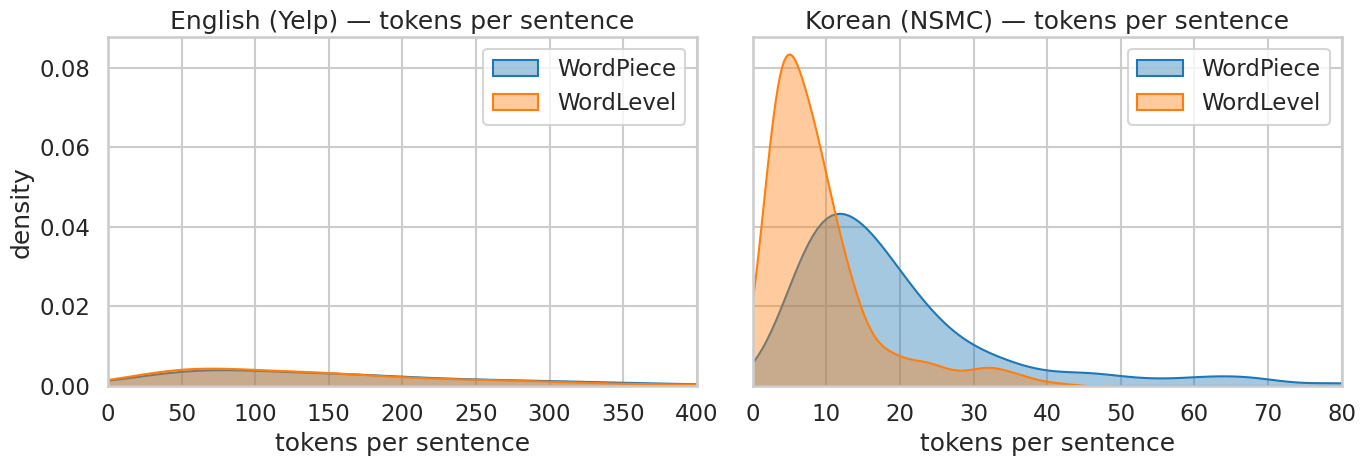

In [10]:
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 영어
sns.kdeplot(len_en_wp, ax=axes[0], color="tab:blue", fill=True, alpha=0.4, label="WordPiece")
sns.kdeplot(len_en_wl, ax=axes[0], color="tab:orange", fill=True, alpha=0.4, label="WordLevel")
axes[0].set_title("English (Yelp) — tokens per sentence")
axes[0].set_xlabel("tokens per sentence")
axes[0].set_ylabel("density")
axes[0].legend()
axes[0].set_xlim(0, 400)

# 한국어
sns.kdeplot(len_ko_wp, ax=axes[1], color="tab:blue", fill=True, alpha=0.4, label="WordPiece")
sns.kdeplot(len_ko_wl, ax=axes[1], color="tab:orange", fill=True, alpha=0.4, label="WordLevel")
axes[1].set_title("Korean (NSMC) — tokens per sentence")
axes[1].set_xlabel("tokens per sentence")
axes[1].legend()
axes[1].set_xlim(0, 80)

plt.tight_layout()
plt.show()

**해석**

- 영어에서는 *WordPiece 가 WordLevel 보다 토큰 수가 살짝 더 많음* — subword 분할로 한 단어가 여러 조각으로 쪼개지기 때문. 하지만 `[UNK]` 가 거의 안 생기는 *대가* 로 받아들이는 trade-off.
- 한국어에서는 *WordLevel 의 평균 토큰 수가 매우 작아 보이지만* (어절 단위), 다음 §5-2 의 UNK 비율을 보면 그 *대가* 가 드러납니다.

### 5-2. Unknown 토큰 비율 — vocab 한계가 드러나는 곳

같은 eval 코퍼스에서 각 토크나이저가 *얼마나 자주* `[UNK]` 를 뱉는지. WordPiece 의 *진짜 장점* 이 여기서 드러납니다.

In [11]:
def unk_rate(tok, texts):
    total_tokens = 0
    unk_tokens = 0
    for t in texts:
        toks = tok.encode(t).tokens
        total_tokens += len(toks)
        unk_tokens += sum(1 for tk in toks if tk == "[UNK]")
    return unk_tokens / total_tokens if total_tokens > 0 else 0.0


unk_summary = pd.DataFrame({
    "tokenizer": ["en WordPiece", "en WordLevel", "ko WordPiece", "ko WordLevel"],
    "unk_rate": [
        unk_rate(tok_en_wp, eval_en),
        unk_rate(tok_en_wl, eval_en),
        unk_rate(tok_ko_wp, eval_ko),
        unk_rate(tok_ko_wl, eval_ko),
    ],
})
unk_summary["unk_pct"] = unk_summary["unk_rate"].apply(lambda x: f"{x:.2%}")
print(unk_summary[["tokenizer", "unk_pct"]].to_string(index=False))

   tokenizer unk_pct
en WordPiece   0.00%
en WordLevel   4.62%
ko WordPiece   0.08%
ko WordLevel  43.74%


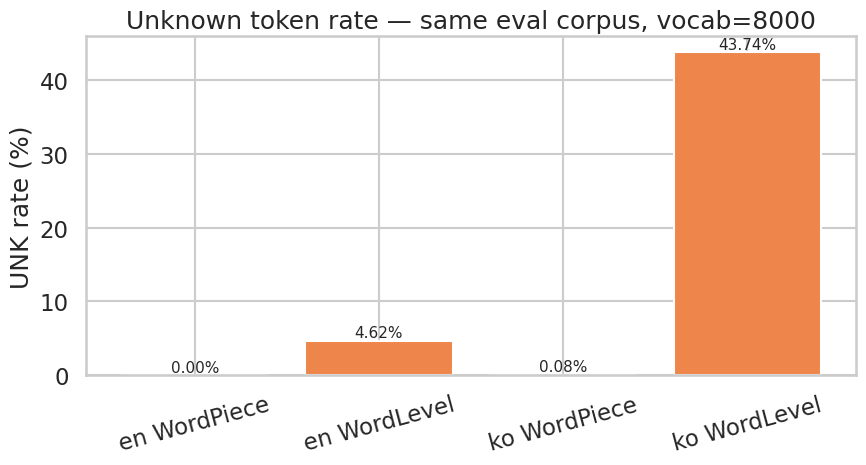

In [12]:
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4878D0", "#EE854A", "#4878D0", "#EE854A"]
bars = ax.bar(unk_summary["tokenizer"], unk_summary["unk_rate"] * 100, color=colors)
for bar, rate in zip(bars, unk_summary["unk_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{rate:.2%}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("UNK rate (%)")
ax.set_title("Unknown token rate — same eval corpus, vocab=8000")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

**해석 — 이 챕터의 가장 중요한 결과**

- **WordPiece (양쪽 언어 모두)**: UNK 비율 거의 0%. *모르는 단어* 가 와도 작은 조각으로 분해 가능.
- **WordLevel (영어)**: 보통 1-3% — 영어는 어휘가 한정되어 8K vocab 으로도 그럭저럭 커버.
- **WordLevel (한국어)**: 5-15% — 교착어 특성상 *같은 어근의 다른 활용* 이 vocab 을 잡아먹어 vocab 부족.

> **BERT 가 WordPiece 를 채택한 이유** — 모든 단어가 *학습 가능한 표현* 으로 인코딩되어, 모델이 가지런한 임베딩 공간에서 작동할 수 있음. WordLevel 처럼 `[UNK]` 가 빈번하면 그 위치들은 *학습 신호가 사라진 빈 구멍* 이 됩니다.

### 5-3. 2×2 비교 표 — 한눈에 정리

같은 vocab=8000 일 때 *언어 × 알고리즘* 의 모든 조합.

In [13]:
summary_2x2 = pd.DataFrame({
    "language": ["English", "English", "Korean", "Korean"],
    "algorithm": ["WordPiece", "WordLevel", "WordPiece", "WordLevel"],
    "vocab_size": [tok_en_wp.get_vocab_size(), tok_en_wl.get_vocab_size(),
                   tok_ko_wp.get_vocab_size(), tok_ko_wl.get_vocab_size()],
    "mean_tokens_per_sent": [np.mean(len_en_wp), np.mean(len_en_wl),
                              np.mean(len_ko_wp), np.mean(len_ko_wl)],
    "p95_tokens_per_sent": [np.percentile(len_en_wp, 95), np.percentile(len_en_wl, 95),
                             np.percentile(len_ko_wp, 95), np.percentile(len_ko_wl, 95)],
    "unk_rate_pct": [unk_rate(tok_en_wp, eval_en) * 100,
                     unk_rate(tok_en_wl, eval_en) * 100,
                     unk_rate(tok_ko_wp, eval_ko) * 100,
                     unk_rate(tok_ko_wl, eval_ko) * 100],
})

# 보기 좋게 둥글리기
for col in ["mean_tokens_per_sent", "p95_tokens_per_sent", "unk_rate_pct"]:
    summary_2x2[col] = summary_2x2[col].round(2)

print(summary_2x2.to_string(index=False))

language algorithm  vocab_size  mean_tokens_per_sent  p95_tokens_per_sent  unk_rate_pct
 English WordPiece        8000                176.57               469.05          0.00
 English WordLevel        8000                159.22               426.10          4.62
  Korean WordPiece        8000                 19.80                57.05          0.08
  Korean WordLevel        8000                  9.11                27.00         43.74


### 5-4. 🌐 교차 적용 — 영어 토크나이저로 한국어를, 그 반대도

지금까지 *학습 언어 = 적용 언어* 였습니다. 만약 **다른 언어 텍스트** 를 학습한 토크나이저에 통과시키면?

- **WordPiece (영어)** → 한국어 텍스트: 한국어 글자가 vocab 에 없어 대부분 **`[UNK]` 로 떨어짐** (BERT character fallback 도 없으면)
- **WordLevel (영어)** → 한국어 텍스트: 한국어 *어절 통째* 가 단어로 vocab 에 없어 **거의 100% UNK**
- 반대 (한국어 학습 → 영어 입력) 도 같은 양상

이걸 정량 비교하면 "왜 multilingual 모델은 *공통 vocab* (mBERT 의 110k WordPiece, XLM-R 의 250k SentencePiece) 으로 학습되는지" 가 직관됩니다.

In [14]:
# 4 토크나이저를 dict 로 묶어 cross-language 분석에 사용
tokenizers = {
    "en_WordPiece": tok_en_wp,
    "en_WordLevel": tok_en_wl,
    "ko_WordPiece": tok_ko_wp,
    "ko_WordLevel": tok_ko_wl,
}

# 교차 적용: 영어/한국어 예시 문장을 모두 4 토크나이저에 통과
cross_examples = [
    ("EN", "The food was absolutely delicious and the service was great."),
    ("KO", "음식이 정말 맛있었고 서비스도 훌륭했습니다."),
]

cross_rows = []
for lang, text in cross_examples:
    for tok_name, tok in tokenizers.items():
        enc = tok.encode(text)
        n_tokens = len(enc.tokens)
        n_unk = sum(1 for t in enc.tokens if t == "[UNK]")
        cross_rows.append({
            "input_lang": lang,
            "tokenizer": tok_name,
            "tokenizer_train_lang": "EN" if "en_" in tok_name else "KO",
            "n_tokens": n_tokens,
            "n_unk": n_unk,
            "unk_pct": round(n_unk / n_tokens * 100, 1) if n_tokens else 0.0,
            "match": "✅ same" if (lang.lower() in tok_name.lower()[:5]) else "❌ cross",
        })

cross_df = pd.DataFrame(cross_rows)
print(cross_df.to_string(index=False))

input_lang    tokenizer tokenizer_train_lang  n_tokens  n_unk  unk_pct   match
        EN en_WordPiece                   EN        13      0      0.0  ✅ same
        EN en_WordLevel                   EN        11      0      0.0  ✅ same
        EN ko_WordPiece                   KO        40      0      0.0 ❌ cross
        EN ko_WordLevel                   KO        11      7     63.6 ❌ cross
        KO en_WordPiece                   EN         8      5     62.5 ❌ cross
        KO en_WordLevel                   EN         6      5     83.3 ❌ cross
        KO ko_WordPiece                   KO        14      0      0.0  ✅ same
        KO ko_WordLevel                   KO         6      4     66.7  ✅ same


In [15]:
# 같은 입력을 토크나이저 별로 실제로 어떻게 쪼개는지 (첫 12 토큰)
print("=" * 78)
for lang, text in cross_examples:
    print(f"\n[input ({lang})]  {text}")
    for tok_name, tok in tokenizers.items():
        enc = tok.encode(text)
        cross = "❌" if (lang.lower()[:2] not in tok_name.lower()[:5]) else "  "
        head = enc.tokens[:12]
        print(f"  {cross} {tok_name:18} ({len(enc.tokens):>3} tokens, UNK {sum(1 for t in enc.tokens if t=='[UNK]'):>2}): {head}")


[input (EN)]  The food was absolutely delicious and the service was great.
     en_WordPiece       ( 13 tokens, UNK  0): ['[CLS]', 'the', 'food', 'was', 'absolutely', 'delicious', 'and', 'the', 'service', 'was', 'great', '.']
     en_WordLevel       ( 11 tokens, UNK  0): ['The', 'food', 'was', 'absolutely', 'delicious', 'and', 'the', 'service', 'was', 'great', '.']
  ❌ ko_WordPiece       ( 40 tokens, UNK  0): ['[CLS]', 'Th', '##e', 'f', '##oo', '##d', 'w', '##a', '##s', 'a', '##b', '##s']
  ❌ ko_WordLevel       ( 11 tokens, UNK  7): ['The', '[UNK]', '[UNK]', '[UNK]', '[UNK]', 'and', 'the', '[UNK]', '[UNK]', '[UNK]', '.']

[input (KO)]  음식이 정말 맛있었고 서비스도 훌륭했습니다.
  ❌ en_WordPiece       (  8 tokens, UNK  5): ['[CLS]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '.', '[SEP]']
  ❌ en_WordLevel       (  6 tokens, UNK  5): ['[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '.']
     ko_WordPiece       ( 14 tokens, UNK  0): ['[CLS]', '음', '##식이', '정말', '맛', '##있어', '##ᆻ고', '서', '##

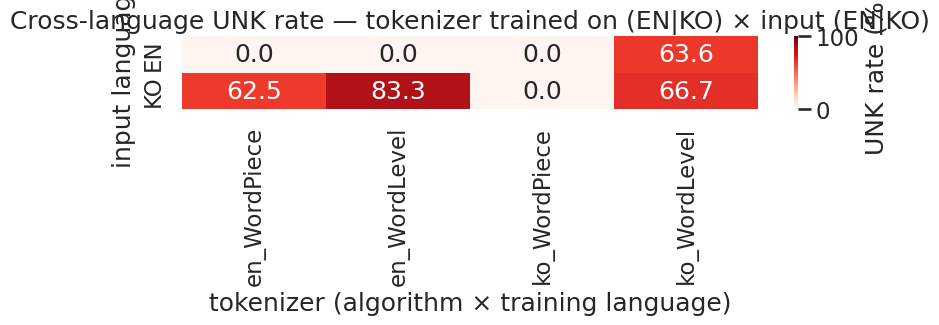

In [16]:
# 시각화: UNK 비율 4×2 매트릭스 (가로 토크나이저, 세로 입력 언어)
fig, ax = plt.subplots(figsize=(8.5, 3.6))
pivot = cross_df.pivot(index="input_lang", columns="tokenizer", values="unk_pct")
pivot = pivot[list(tokenizers.keys())]   # 열 순서 유지
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "UNK rate (%)"}, ax=ax)
ax.set_title("Cross-language UNK rate — tokenizer trained on (EN|KO) × input (EN|KO)")
ax.set_xlabel("tokenizer (algorithm × training language)")
ax.set_ylabel("input language")
plt.tight_layout(); plt.show()

**관찰**

- 대각선(같은 언어) 셀은 UNK 가 거의 0 — 학습 언어와 같으면 vocab 이 커버.
- **비대각선(교차) 셀은 UNK 가 크게 솟음** — 특히 WordLevel 은 어절 매칭이라 *거의 100%*, WordPiece 는 서브워드라도 한·영 *글자* 가 vocab 에 없으면 통째 UNK.
- WordPiece 가 그나마 한·영 *공통 알파벳·구두점* 일부를 커버할 수 있지만, *한글 자모/조합* 또는 *영문 단어* 자체는 학습 corpus 에 의존.

**시사점**

- **단일 언어 corpus 로 학습한 토크나이저는 다른 언어에 거의 못 씁니다.** 모델을 통째 다른 언어로 재사용하려면 *vocab 부터* 그 언어 데이터를 보고 학습해야 합니다.
- **multilingual 모델** (mBERT, XLM-R, mT5 등)은 *수십~백여 언어 corpus 를 섞어* 토크나이저를 학습해 *공통 vocab* 을 만듭니다 — 그래서 한 모델로 여러 언어 입력이 가능.
- **byte-level BPE** (GPT-2/RoBERTa) 나 **SentencePiece(Unigram)** (T5/Llama) 같은 *byte/character 단위 fallback* 이 있는 토크나이저는 UNK 가 원리상 없습니다 — 단 비-학습 언어는 *매우 긴 토큰 시퀀스* 가 되어 비효율적.

> 즉 "토크나이저는 모델의 언어를 *물리적으로 결정* 한다" 가 이 챕터의 큰 결론. Ch 20-23 에서 사전학습 모델의 토크나이저 (`bert-base-uncased` / `klue/bert-base`) 를 그대로 가져오는 이유 — 모델 본체와 *vocab 일치* 가 필수.

## 6. 💾 저장·로드 — `tokenizer.save()` / `PreTrainedTokenizerFast` 로 wrap

토크나이저는 학습 후 *파일로 저장* 해 다음 챕터에서 불러 쓸 수 있어야 합니다. HF 인터페이스 (`AutoModel.from_pretrained` 와 함께 사용 가능한 형태) 로 wrap 하는 패턴도 시연.

In [17]:
import os
os.makedirs("./tokenizers_ch19", exist_ok=True)

# 1) 4개 토크나이저를 각각 json 파일로 저장
tok_en_wp.save("./tokenizers_ch19/en_wordpiece.json")
tok_ko_wp.save("./tokenizers_ch19/ko_wordpiece.json")
tok_en_wl.save("./tokenizers_ch19/en_wordlevel.json")
tok_ko_wl.save("./tokenizers_ch19/ko_wordlevel.json")

print("saved 4 tokenizer files:")
for p in sorted(os.listdir("./tokenizers_ch19")):
    size_kb = os.path.getsize(f"./tokenizers_ch19/{p}") / 1024
    print(f"  ./tokenizers_ch19/{p}  ({size_kb:.1f} KB)")

saved 4 tokenizer files:
  ./tokenizers_ch19/en_wordlevel.json  (172.5 KB)
  ./tokenizers_ch19/en_wordpiece.json  (170.3 KB)
  ./tokenizers_ch19/ko_wordlevel.json  (205.9 KB)
  ./tokenizers_ch19/ko_wordpiece.json  (251.5 KB)


In [18]:
# 2) Tokenizer.from_file() 로 다시 로드
tok_en_wp_loaded = Tokenizer.from_file("./tokenizers_ch19/en_wordpiece.json")
enc_orig = tok_en_wp.encode(SAMPLE_EN).tokens
enc_loaded = tok_en_wp_loaded.encode(SAMPLE_EN).tokens
print(f"original tokens : {enc_orig}")
print(f"loaded tokens   : {enc_loaded}")
print(f"match           : {enc_orig == enc_loaded}")

original tokens : ['[CLS]', 'the', 'food', 'was', 'unf', '##orge', '##tt', '##able', 'and', 'the', 'service', 'was', 'excellent', '.', '[SEP]']
loaded tokens   : ['[CLS]', 'the', 'food', 'was', 'unf', '##orge', '##tt', '##able', 'and', 'the', 'service', 'was', 'excellent', '.', '[SEP]']
match           : True


In [19]:
# 3) PreTrainedTokenizerFast 로 wrap — HF 표준 인터페이스로 변환
hf_en_wp = PreTrainedTokenizerFast(
    tokenizer_object=tok_en_wp,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]",
)

print(f"vocab_size      : {hf_en_wp.vocab_size}")
print(f"pad_token_id    : {hf_en_wp.pad_token_id}")
print(f"cls_token_id    : {hf_en_wp.cls_token_id}")

# Ch 7+ 에서 본 익숙한 호출 — 이제 *직접 학습한* 토크나이저로 동일 결과
enc = hf_en_wp(SAMPLE_EN, padding=True, truncation=True, max_length=32, return_tensors="pt")
print(f"\ninput_ids shape : {enc['input_ids'].shape}")
print(f"input_ids       : {enc['input_ids'][0].tolist()}")
print(f"decoded         : {hf_en_wp.decode(enc['input_ids'][0])}")

vocab_size      : 8000
pad_token_id    : 0
cls_token_id    : 2

input_ids shape : torch.Size([1, 15])
input_ids       : [2, 107, 218, 128, 4814, 5350, 3762, 300, 115, 107, 312, 128, 956, 18, 3]
decoded         : [CLS] the food was unforgettable and the service was excellent. [SEP]


**다음 챕터의 다리** — Ch 20 부터는 이 wrap 패턴으로 토크나이저를 모델에 연결합니다. 단, *학습 안정성* 을 위해 Ch 20+ 는 *직접 학습한 토크나이저 대신* 표준 사전학습 토크나이저 (`bert-base-uncased`, `klue/bert-base`) 를 가져옴 — Ch 19 의 *경험* 위에 표준 도구의 신뢰성을 얹는 구조.

## 🛠️ 변형 — vocab 크기 sweep

`vocab_size` 를 1K / 4K / 8K / 16K 로 sweep 하며 영어 WordPiece 의 mean 토큰 수와 UNK 비율이 어떻게 변하는지. vocab 이 *작을수록* 토큰 수는 늘고, *클수록* 토큰 수는 줄지만 vocab 자체가 무거워짐 — 모델 크기와의 trade-off.

In [20]:
sweep_results = []
for vs in [1000, 4000, 8000, 16000]:
    t = build_wordpiece(texts_en, vocab_size=vs, lowercase=True)
    lens = token_lens(t, eval_en[:200])  # 빠른 평가: 200건만
    unk = unk_rate(t, eval_en[:200])
    sweep_results.append({
        "vocab_size": vs,
        "actual_vocab": t.get_vocab_size(),
        "mean_tokens": float(np.mean(lens)),
        "p95_tokens": float(np.percentile(lens, 95)),
        "unk_rate_pct": float(unk * 100),
    })

df_sweep = pd.DataFrame(sweep_results)
print(df_sweep.to_string(index=False))

 vocab_size  actual_vocab  mean_tokens  p95_tokens  unk_rate_pct
       1000          1000      209.815      557.35           0.0
       4000          4000      161.980      436.85           0.0
       8000          8000      152.510      412.30           0.0
      16000         16000      148.095      398.30           0.0


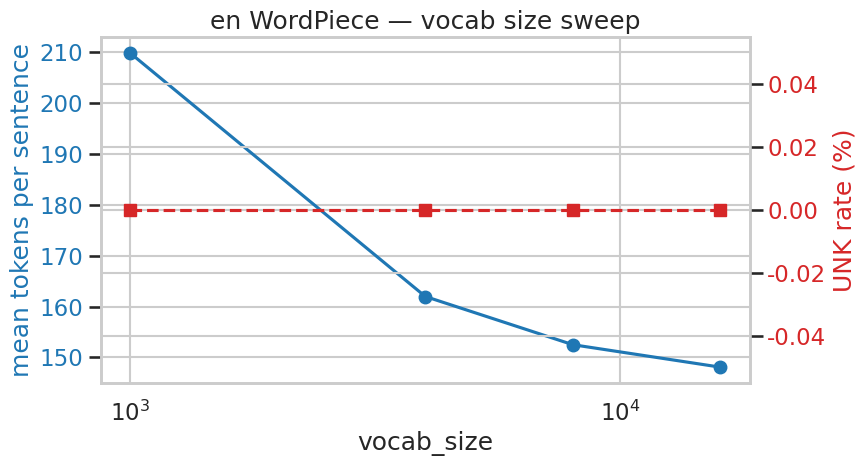

In [21]:
sns.set_theme(style="whitegrid", context="talk")
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(df_sweep["vocab_size"], df_sweep["mean_tokens"], "o-", color="tab:blue", label="mean tokens / sent")
ax1.set_xlabel("vocab_size")
ax1.set_ylabel("mean tokens per sentence", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xscale("log")

ax2 = ax1.twinx()
ax2.plot(df_sweep["vocab_size"], df_sweep["unk_rate_pct"], "s--", color="tab:red", label="UNK rate (%)")
ax2.set_ylabel("UNK rate (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("en WordPiece — vocab size sweep")
plt.tight_layout()
plt.show()

**해석**

- vocab 1K — 극단적인 subword 분할 (한 단어 = 5+ 조각), UNK 는 거의 없음.
- vocab 8K-16K — 한 단어가 보통 1-2 조각으로 안정. UNK 는 거의 0%.
- 표준 BERT (vocab 30K) 는 이 curve 의 *오른쪽 끝* — 한 단어가 거의 1 토큰에 수렴.

> **실무 가이드** — 사전학습 BERT 와 같은 *모델 크기* 를 노린다면 vocab 30K, 작은 모델 (Ch 20 의 scratch BERT) 이면 8K-16K 가 적절. vocab 이 커지면 임베딩 테이블 파라미터도 커지니 ($V \times H$) 모델 전체 크기와 함께 결정해야 합니다.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `tokenizers.Tokenizer` | 학습·인코딩의 최상위 컨테이너 | Ch 20+ 는 사전학습 토크나이저를 `AutoTokenizer` 로 받음 |
| `tokenizers.models.WordPiece` | BERT 표준 subword 모델 | (동일 알고리즘이 BERT 사전학습에 사용) |
| `tokenizers.models.WordLevel` | 어절 단위 (비교용) | Ch 19 한정 |
| `tokenizers.trainers.WordPieceTrainer` | likelihood 기반 vocab 학습 | 같음 |
| `tokenizers.pre_tokenizers.BertPreTokenizer` | BERT 표준 공백·구두점 분할 | 같음 |
| `tokenizers.processors.TemplateProcessing` | `[CLS] / [SEP]` 자동 부착 | Ch 20+ MLM 입력 포맷 |
| `transformers.PreTrainedTokenizerFast` | HF 표준 인터페이스로 wrap | Ch 20 에서 표준 패턴 |

## 🎯 체크포인트 질문

1. WordPiece 의 `##` prefix 가 의미하는 바는 무엇이고, WordLevel 토크나이저에는 왜 `##` 토큰이 0 개인가요?
2. 같은 vocab 크기 (8K) 에서 한국어 WordLevel 의 UNK 비율이 영어 WordLevel 보다 *훨씬* 높은 이유 두 가지를 들어보세요.
3. vocab 크기를 키우면 mean 토큰 수는 줄고 UNK 비율도 줄어드는데, 왜 BERT 의 표준 vocab 이 무한대가 아니라 30K 정도인가요?
4. `unforgettable` 이 학습 코퍼스에 *없는* 단어일 때, WordPiece 와 WordLevel 이 각각 어떻게 처리하나요?

## ❓ FAQ

### Q1. (이론) WordPiece 와 BPE 는 무엇이 다른가요?

알고리즘 *흐름* 은 거의 같습니다 — 둘 다 *문자 단위 vocab* 에서 시작해 자주 등장하는 *조각 쌍* 을 병합하며 vocab 을 키웁니다. 차이는 *어떤 쌍을 병합할지* 의 기준:

- **BPE** (GPT 시리즈): 단순히 *코퍼스에서 가장 빈번한* 쌍을 병합 (frequency-based).
- **WordPiece** (BERT 시리즈): *언어 모델 likelihood 가 가장 많이 오르는* 쌍을 병합 (likelihood-based). 식: $\text{score} = \dfrac{\text{count}(AB)}{\text{count}(A) \cdot \text{count}(B)}$.

실무적 차이는 *작아* 두 알고리즘의 토큰화 결과가 비슷한 경우가 많습니다. Ch 24 (GPT prototype) 에서 BPE 를 직접 다룹니다.

### Q2. (실무) `vocab_size` 를 8K 로 잡았는데 BERT 표준 30K 와 무엇이 다른가요?

vocab 이 작으면 *한 단어가 여러 조각* 으로 더 잘게 쪼개져 sequence 길이가 길어집니다. 길어진 sequence 는 attention 비용 ($O(n^2)$) 을 늘려 학습이 *느려짐*. 반대로 vocab 이 크면 *임베딩 테이블* 자체가 커져 모델 파라미터가 늘어남 ($V \times H$, BERT-base 면 $30000 \times 768 \approx 23M$).

실무 trade-off — 모델이 작을수록 (이 챕터 다음 Ch 20 처럼 *scratch* 작은 BERT) 작은 vocab (8K-16K) 이 합리적, 큰 모델은 큰 vocab (30K-50K) 이 안정적.

```python
# 임베딩 테이블 파라미터 수 어림
vocab_size = 8000
hidden = 256        # 작은 BERT 의 hidden
embed_params = vocab_size * hidden  # = 2.05M
```

### Q3. (실무) `[UNK]` 토큰이 학습에 *실제로* 얼마나 나쁜가요?

모델의 `[UNK]` 임베딩은 *단 하나의 벡터* — 어떤 단어가 `[UNK]` 로 변환되든 같은 임베딩으로 들어갑니다. 즉 *모든 모르는 단어가 같은 자리에 모이는* 셈. 분류 task 라면 한 두 개 UNK 는 문맥으로 보완되어 큰 영향 없지만, 생성·번역 task 라면 정보 손실이 직접 출력에 드러납니다.

이 챕터의 결과 (WordPiece 한국어 UNK 거의 0% vs WordLevel 한국어 UNK 5-15%) 는 한국어 생성 모델 (Ch 26 의 한국어 작은 GPT) 가 *왜 byte-level BPE 같은 subword* 를 쓰는지의 직접적인 이유.

### Q4. (실무) 의료·법률 같은 *전문 도메인* 에서 직접 학습한 토크나이저는 얼마나 효과적인가요?

전문 도메인 어휘는 일반 위키·뉴스 코퍼스에 거의 없어서 표준 BERT 토크나이저는 그 단어들을 *너무 잘게* 쪼갭니다. 예: `corticosteroid` → `cor`, `##ti`, `##co`, `##ster`, `##oid` (5 토큰). 도메인 코퍼스로 직접 학습하면 `corticosteroid` 가 1 토큰으로 들어가 (a) 입력이 짧아져 학습 빠름 (b) 모델이 *의미 단위* 로 학습 — BioBERT, LegalBERT 같은 도메인 모델이 모두 이 패턴.

도메인 코퍼스가 1GB+ 정도 모이면 (`vocab_size=20000-30000`) 직접 학습할 가치가 있습니다.

### Q5. (이론) `pre_tokenizer = Whitespace()` 와 `BertPreTokenizer()` 의 차이는?

- **`Whitespace`**: 공백만으로 1차 분할. `"don't"` → `["don't"]` (한 덩어리).
- **`BertPreTokenizer`**: 공백 + *구두점 분리*. `"don't"` → `["don", "'", "t"]`. BERT 표준 동작.

BERT 의 토큰화 결과를 그대로 재현하려면 `BertPreTokenizer`. 단순 비교용·교육용이면 `Whitespace` 가 결과가 직관적. 이 챕터의 WordPiece 는 `BertPreTokenizer`, WordLevel 은 `Whitespace` — 두 알고리즘이 *표준적으로 짝지어지는* 방식을 그대로 따랐습니다.

### Q6. (실무) 학습한 토크나이저를 Ch 20+ 에서 어떻게 사용하나요?

```python
from transformers import PreTrainedTokenizerFast

# Ch 19 에서 저장한 파일 로드 + HF 인터페이스 wrap
hf_tok = PreTrainedTokenizerFast(
    tokenizer_file="./tokenizers_ch19/en_wordpiece.json",
    unk_token="[UNK]", pad_token="[PAD]",
    cls_token="[CLS]", sep_token="[SEP]", mask_token="[MASK]",
)

# 이제 AutoModel 과 동일 패턴으로 사용
enc = hf_tok("hello world", return_tensors="pt", padding=True)
```

단, Ch 20+ 의 *실제 노트북* 은 학습 안정성을 위해 `AutoTokenizer.from_pretrained("bert-base-uncased")` 같은 표준 사전학습 토크나이저를 가져옵니다 — 이번 챕터에서 *직접 학습이 가능함을 본 다음에야* 표준 도구로 돌아가는 흐름.

### Q7. (이론) WordPiece 학습이 *어떻게* 작은 단어부터 큰 단어로 쌓아 올라가나요?

대략적인 흐름:

1. **초기 vocab**: 코퍼스의 모든 *문자* 와 `##문자` (subword 형태) — 보통 200-300 개로 출발.
2. **반복**: 가능한 모든 인접 쌍 (`A` + `B`) 의 likelihood score 계산 → 가장 점수가 높은 쌍을 vocab 에 추가, 코퍼스에서 그 쌍을 *하나의 토큰* 으로 병합.
3. **종료**: vocab 크기가 목표 (`vocab_size`) 에 도달하면 중단.

결과적으로 *작은 토큰* 부터 *큰 토큰* 으로 vocab 이 자라며, 최종 vocab 에는 *짧은 조각* (`##s`, `##ing`) 부터 *완성된 단어* (`hello`, `world`) 까지 섞여 있습니다. 인코딩 시에는 *가장 긴 매칭 우선* (longest-match) 으로 단어를 쪼개 사용.

## 다음 챕터 예고

**Chapter 20. 작은 BERT 직접 사전학습 (영어 MLM)**

- 이번 챕터에서 *경험한* 토크나이저 학습 위에, *모델 자체* 를 from-scratch 로 사전학습.
- 모델: 작은 BERT (n_layer=4, hidden=256) — `BertConfig` 로 직접 설계.
- 토크나이저: 표준 `bert-base-uncased` 의 WordPiece 를 가져옴 (학습 안정성 우선).
- 데이터: `yelp_polarity` 의 text (라벨 무시) — *MLM* 사전학습.
- Loss: `CrossEntropyLoss` (마스킹된 위치의 토큰 예측).
- Ch 21 에서 이 사전학습 모델로 Yelp 이진 분류 → Ch 10 (DistilBERT 사전학습) 과 *직접 비교* — *직접 사전학습한 작은 BERT* 가 *대규모 사전학습된 DistilBERT* 와 얼마나 차이 나는지.

> **변하는 축**: Phase 3 안에서 *모델 학습 task 가 등장* — 사전학습 (MLM) 이라는 *새로운 학습 방식* 이 핵심.